# Importing the National Elevation Dataset

Brendan Harmon  
2026-08-30

<figure>
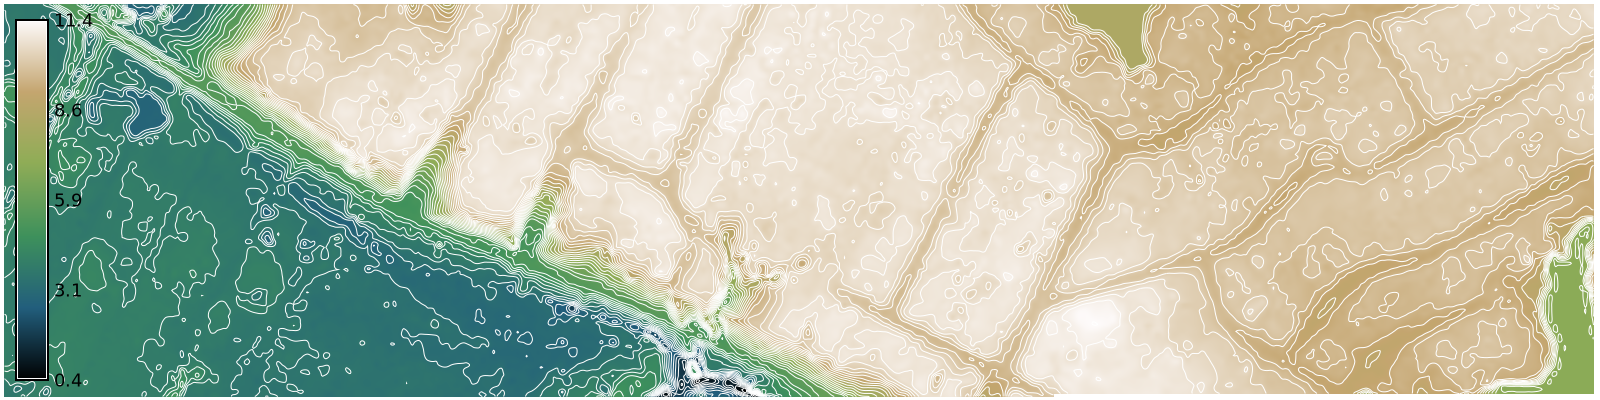
<figcaption aria-hidden="true">Data acquisition</figcaption>
</figure>

Learn how to import the National Elevation Dataset into GRASS via the
National Map Access API.

## Setup

Start a GRASS session in a new project. Set the coordinate reference
system for the project to Louisiana State Plane South using EPSG code
2801.

In [1]:
# Import modules
import sys
import subprocess
import numpy as np

# Find GRASS Python packages
sys.path.append(
  subprocess.check_output(
    ["grass", "--config", "python_path"],
    text=True
    ).strip()
  )

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj
from grass.tools import Tools

# Create GRASS project
gs.create_project("hilltop", epsg="2801", overwrite=True)

# Initialize GRASS session
gj.init("hilltop")
tools = Tools(overwrite=True)

# Print projection
projection = tools.g_proj(format="shell", flags="p").keyval
print(projection.get("name"))

## Set computational region

In [2]:
# Set region
tools.g_region(n=206040, s=205640, e=1023700, w=1022100, res=1)

## Install extension

In [3]:
# Install extension
tools.g_extension(extension="r.in.usgs")

## Download elevation

In [4]:
# Download elevation data
tools.r_in_usgs(product="ned", ned_dataset="ned19sec", output_name="ned")

## Visualize elevation

In [5]:
# Set region resolution
tools.g_region(res=1)

# Supersample elevation
tools.r_resamp_interp(input="ned", output="elevation", method="bicubic")

# Compute contours
tools.r_contour(input="elevation", output="contours", step=0.3)

# Visualize
m = gj.Map(width=1600)
m.d_rast(map="elevation")
m.d_vect(map="contours", color="white")
m.d_legend(raster="elevation", at=(5, 95, 1, 3))
m.show()

<figure>
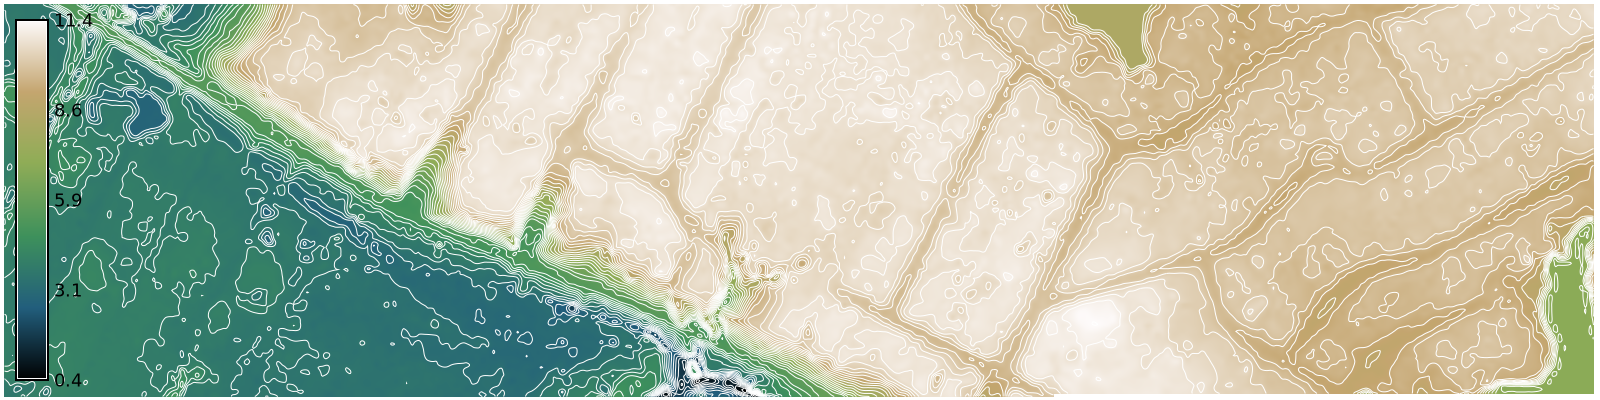
<figcaption aria-hidden="true">Elevation</figcaption>
</figure>

## Export elevation

In [6]:
# Export elevation
tools.r_out_gdal(input="elevation", output="elevation.tif", format="GTiff")

# Export contours
tools.v_out_ogr(input="contours", output="contours.gpkg", format="GPKG")

# Export contours for computer aided design
tools.v_out_dxf(input="contours", output="contours.dxf")